In [1]:
import numpy as np
import pandas as pd

In [2]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
import datetime
from datetime import datetime as dt

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv('path_data.csv',index_col='customer_no')
df = df[['path']]

In [6]:
df.head()

,path
customer_no,
1,dd
2,ddd
3,dd
4,dddd
5,s


In [7]:

df.tail()

,path
customer_no,
9506,dd
9507,dd
9508,dd
9509,NaN
9510,NaN


In [8]:
df.isna().sum()

path    4
dtype: int64

In [9]:
df.fillna('',inplace=True)
df.tail()

,path
customer_no,
9506,dd
9507,dd
9508,dd
9509,
9510,


In [10]:
df_trans = df.copy()
df_trans = 'e' + df_trans[['path']] + 'cc'
df_trans.head()

,path
customer_no,
1,eddcc
2,edddcc
3,eddcc
4,eddddcc
5,escc


In [11]:

df_trans.tail()

,path
customer_no,
9506,eddcc
9507,eddcc
9508,eddcc
9509,ecc
9510,ecc


In [12]:
df_trans.to_csv('path_data_corrected.csv')

In [13]:
dict_ = {'e':'entry','d':'dairy','s':'spices','k':'drinks','f':'fruit','c':'checkout'}

In [14]:
def zero_matrix(dict_):
    matrix = {}
    for location in dict_.values():
        matrix[location] = [0 for i in range(len(dict_))]   
    df = pd.DataFrame(index=dict_.values(),data=matrix)
    return df

In [15]:
def transition_matrix(path,dict_):
    matrix = zero_matrix(dict_)
    trans = [ path[i:i+2] for i in range(len(path)-1) ]
    for tran in trans:
        row, column = dict_[tran[0]], dict_[tran[1]]
        matrix.loc[row][column] += 1
    
    return matrix

In [16]:
tran_matrix = df_trans['path'].apply(lambda x: transition_matrix(x,dict_)).sum()
tran_matrix

,entry,dairy,spices,drinks,fruit,checkout
entry,0,2140,1350,1142,2809,4
dairy,0,13105,913,1041,885,1837
spices,0,1213,2525,1024,571,945
drinks,0,106,846,5821,855,2097
fruit,0,1217,644,697,7591,2562
checkout,0,0,0,0,0,7445


In [17]:
from sklearn.preprocessing import normalize

def normed_matrix(matrix): 
    normed_matrix = normalize(matrix, norm='l1')
    normed_matrix = pd.DataFrame( normed_matrix,index=tran_matrix.index,columns=tran_matrix.columns)
    return normed_matrix

In [18]:
tm = normed_matrix(tran_matrix)
tm

,entry,dairy,spices,drinks,fruit,checkout
entry,0.0,0.287441,0.181330,0.153392,0.377300,0.000537
dairy,0.0,0.737023,0.051347,0.058546,0.049772,0.103313
spices,0.0,0.193214,0.402198,0.163109,0.090953,0.150526
drinks,0.0,0.010900,0.086992,0.598560,0.087918,0.215630
fruit,0.0,0.095744,0.050665,0.054834,0.597199,0.201558
checkout,0.0,0.000000,0.000000,0.000000,0.000000,1.000000


In [19]:
tm.to_csv('transition_matrix.csv',index=None)


In [21]:
trans_mat = pd.read_csv('transition_matrix.csv')
trans_mat.set_index(trans_mat.columns,inplace=True)
trans_mat

,entry,dairy,spices,drinks,fruit,checkout
entry,0.0,0.287441,0.181330,0.153392,0.377300,0.000537
dairy,0.0,0.737023,0.051347,0.058546,0.049772,0.103313
spices,0.0,0.193214,0.402198,0.163109,0.090953,0.150526
drinks,0.0,0.010900,0.086992,0.598560,0.087918,0.215630
fruit,0.0,0.095744,0.050665,0.054834,0.597199,0.201558
checkout,0.0,0.000000,0.000000,0.000000,0.000000,1.000000


In [22]:
a = list(tm.columns)
p = {}
for location in tm.index: p[location] = list(tm.loc[location])

In [23]:
def next_state(initial):
    next_state = np.random.choice(a=a,size=1,p=p[initial])
    return str(next_state[0])

In [24]:
next_state('spices')

'spices'

In [25]:
def matrix_power(matrix,k):
    m = np.array(matrix)
    prod = np.identity(m.shape[0])
    for k in range(k):
        prod = prod.dot(m)
    
    prod = pd.DataFrame(prod,index=matrix.index,columns=matrix.columns)
    return prod

In [26]:

matrix_power(tm,10)

,entry,dairy,spices,drinks,fruit,checkout
entry,0.0,0.089569,0.025194,0.048311,0.045627,0.791299
dairy,0.0,0.102867,0.026761,0.050323,0.045941,0.774107
spices,0.0,0.076457,0.021857,0.042427,0.038909,0.820350
drinks,0.0,0.050248,0.016692,0.034058,0.030911,0.868091
fruit,0.0,0.065299,0.018633,0.035488,0.035099,0.845480
checkout,0.0,0.000000,0.000000,0.000000,0.000000,1.000000


In [27]:

def survival_probability(minute):
    state_vector = np.array([1.,0.,0.,0.,0.,0.])
    prob_list = [1.]
    for i in range(minute):
        state_vector =  state_vector.dot(tm)
        probability = 1.- state_vector[-1]
        prob_list.append(probability)
    return prob_list

Text(0.5, 0, 'minute')

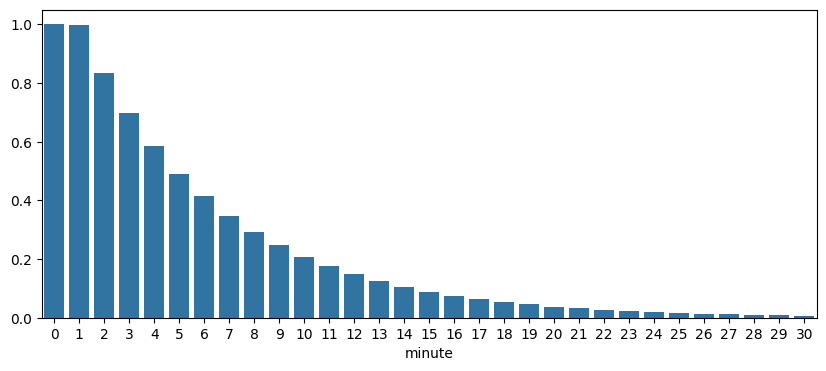

In [28]:
plt.figure(figsize=(10,4),dpi=100)
minutes = list(range(31))
prob_list = survival_probability(30)
sns.barplot(x=minutes,y=prob_list)
plt.xlabel('minute')